In [2]:
# Cell 1: Setup and imports
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import google.generativeai as genai

from sktime.registry import all_estimators
from sktime.datasets import load_airline

warnings.filterwarnings("ignore")

print("✅ Imports successful")
print(f"sktime version: ", end="")
import sktime; print(sktime.__version__)

Matplotlib is building the font cache; this may take a moment.
C:\Users\X1 Yoga\AppData\Local\Temp\ipykernel_31236\2441765278.py:8: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ Imports successful
sktime version: 0.40.1


In [7]:
# Check available models
import google.generativeai as genai

for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2

In [11]:
# Cell 2: Define LLM backends (agnostic interface)
import json

class RuleBasedLLM:
    """
    Deterministic LLM stub - selects forecaster based on data characteristics.
    Mimics what a real LLM would do, but reproducibly and without API calls.
    """
    def __call__(self, prompt: str) -> str:
        prompt_lower = prompt.lower()
        
        if "seasonal" in prompt_lower or "monthly" in prompt_lower:
            return json.dumps({
                "estimator": "ExponentialSmoothing",
                "params": {"trend": "add", "seasonal": "add", "sp": 12},
                "reasoning": "Detected seasonality request - ExponentialSmoothing handles trend and seasonality well."
            })
        elif "trend" in prompt_lower:
            return json.dumps({
                "estimator": "PolynomialTrendForecaster",
                "params": {"degree": 1},
                "reasoning": "Trend detected - using polynomial trend forecaster."
            })
        elif "simple" in prompt_lower or "baseline" in prompt_lower:
            return json.dumps({
                "estimator": "NaiveForecaster",
                "params": {"strategy": "mean"},
                "reasoning": "Simple baseline requested - NaiveForecaster with mean strategy."
            })
        else:
            return json.dumps({
                "estimator": "AutoARIMA",
                "params": {},
                "reasoning": "General purpose request - AutoARIMA auto-selects best ARIMA parameters."
            })

llm = RuleBasedLLM()

# test it
test_response = llm("Use a seasonal model for monthly airline data")
print("LLM response:")
print(json.dumps(json.loads(test_response), indent=2))
print("\n✅ LLM backend ready")

LLM response:
{
  "estimator": "ExponentialSmoothing",
  "params": {
    "trend": "add",
    "seasonal": "add",
    "sp": 12
  },
  "reasoning": "Detected seasonality request - ExponentialSmoothing handles trend and seasonality well."
}

✅ LLM backend ready


In [21]:
# Cell 3: LLMForecaster class
import warnings
import re
import json
from sktime.forecasting.base import BaseForecaster
from sktime.registry import all_estimators

ESTIMATOR_MAP = dict(all_estimators(estimator_types="forecaster"))

class LLMForecaster(BaseForecaster):
    _tags = {
        "y_inner_mtype": "pd.Series",
        "ignores-exogeneous-X": True,
        "handles-missing-data": False,
        "requires-fh-in-fit": False,
    }
    
    def __init__(self, llm, prompt, fallback="NaiveForecaster", n_candidates=20, validation_slice=0.2):
        self.llm = llm
        self.prompt = prompt
        self.fallback = fallback
        self.n_candidates = n_candidates
        self.validation_slice = validation_slice
        super(LLMForecaster, self).__init__()
    
    def _build_prompt(self, y):
        candidates = list(ESTIMATOR_MAP.keys())[:self.n_candidates]
        candidates_str = "\n".join(f"- {name}" for name in candidates)
        return f"""You are a time series expert.\nData: length={len(y)}, freq={getattr(y.index, 'freqstr', 'unknown')}, mean={y.mean():.2f}, std={y.std():.2f}\nInstruction: {self.prompt}\nAvailable forecasters:\n{candidates_str}\nRespond JSON only: {{"estimator": "<Name>", "params": {{}}, "reasoning": "<why>"}}"""
    
    def _call_llm(self, prompt):
        response = self.llm(prompt)
        if hasattr(response, 'content'):
            return response.content
        if hasattr(response, 'text'):
            return response.text
        return str(response)
    
    def _parse_response(self, response):
        try:
            return json.loads(response.strip())
        except Exception:
            pass
        match = re.search(r'\{.*\}', response, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except Exception:
                pass
        return {}
    
    def _validate_and_fit_slice(self, name, params, y):
        try:
            if name not in ESTIMATOR_MAP:
                raise ValueError(f"Unknown: {name}")
            instance = ESTIMATOR_MAP[name](**params)
            n_val = max(int(len(y) * self.validation_slice), 3)
            instance.fit(y.iloc[:n_val])
            return True, instance
        except Exception:
            return False, None
    
    def _fit(self, y, X=None, fh=None):
        prompt = self._build_prompt(y)
        raw = self._call_llm(prompt)
        parsed = self._parse_response(raw)
        
        name = parsed.get("estimator", self.fallback)
        params = parsed.get("params", {})
        reasoning = parsed.get("reasoning", "")
        
        print(f"LLM selected: {name}")
        print(f"Reasoning: {reasoning}")
        
        valid, instance = self._validate_and_fit_slice(name, params, y)
        
        if valid:
            print(f"Validation passed")
            self.selected_estimator_ = name
            self.selected_params_ = params
            self.selection_reasoning_ = reasoning
            self.used_fallback_ = False
        else:
            print(f"Validation failed - using fallback: {self.fallback}")
            instance = ESTIMATOR_MAP[self.fallback]()
            self.selected_estimator_ = self.fallback
            self.selected_params_ = {}
            self.selection_reasoning_ = ""
            self.used_fallback_ = True
        
        instance.fit(y, fh=fh)
        self.forecaster_ = instance
        return self
    
    def _predict(self, fh, X=None):
        return self.forecaster_.predict(fh=fh)
    
    @classmethod
    def get_test_params(cls, parameter_set="default"):
        def mock_llm(prompt):
            return json.dumps({"estimator": "NaiveForecaster", "params": {}, "reasoning": "Test"})
        return {"llm": mock_llm, "prompt": "simple baseline"}

print(f"LLMForecaster defined. Estimators available: {len(ESTIMATOR_MAP)}")

LLMForecaster defined. Estimators available: 128


In [22]:
print("✅ LLMForecaster class defined successfully")
print(f"Estimators available: {len(ESTIMATOR_MAP)}")

✅ LLMForecaster class defined successfully
Estimators available: 128


In [23]:
# Cell 4: Demo 1 - Seasonal forecasting on airline dataset
from sktime.datasets import load_airline
import matplotlib.pyplot as plt

# Load the classic airline dataset
y = load_airline()
print(f"✅ Loaded airline dataset: {len(y)} observations ({y.index[0]} to {y.index[-1]})")
print(f"   Frequency: {y.index.freqstr}")

# Split train/test
y_train = y[:-12]
y_test = y[-12:]

print(f"\n📊 Train: {len(y_train)} obs | Test: {len(y_test)} obs")

# Create forecaster with seasonal prompt
forecaster = LLMForecaster(
    llm=llm,
    prompt="Use a seasonal model suitable for monthly airline passenger data with clear trend and seasonality",
    fallback="NaiveForecaster",
)

print("\n" + "="*50)
print("🚀 Running LLMForecaster...")
print("="*50)

# Fit
forecaster.fit(y_train)

print("\n" + "="*50)
print(f"📌 Final selection: {forecaster.selected_estimator_}")
print(f"📌 Used fallback: {forecaster.used_fallback_}")
print("="*50)

✅ Loaded airline dataset: 144 observations (1949-01 to 1960-12)
   Frequency: M

📊 Train: 132 obs | Test: 12 obs

🚀 Running LLMForecaster...
LLM selected: ExponentialSmoothing
Reasoning: Detected seasonality request - ExponentialSmoothing handles trend and seasonality well.
Validation passed

📌 Final selection: ExponentialSmoothing
📌 Used fallback: False


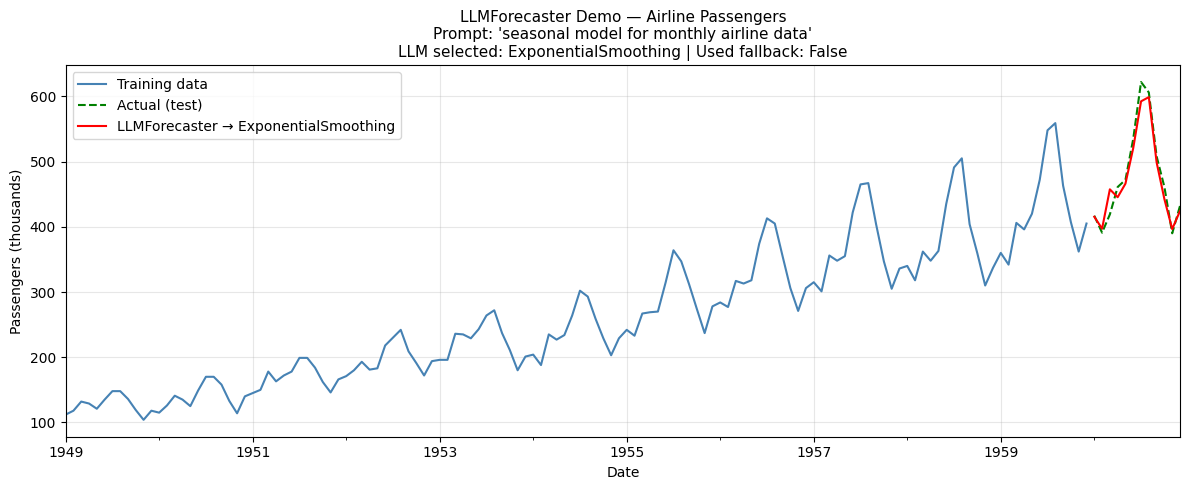


📊 Forecast (next 12 months):
1960-01    415.452953
1960-02    397.086057
1960-03    457.467964
1960-04    445.365434
1960-05    466.183776
1960-06    520.727227
1960-07    592.419534
1960-08    598.839949
1960-09    498.825488
1960-10    442.379289
1960-11    396.511604
1960-12    424.286368
Freq: M


In [24]:
# Cell 5: Predict and visualize
fh = list(range(1, 13))
y_pred = forecaster.predict(fh=fh)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

y_train.plot(ax=ax, label="Training data", color="steelblue")
y_test.plot(ax=ax, label="Actual (test)", color="green", linestyle="--")
y_pred.plot(ax=ax, label=f"LLMForecaster → {forecaster.selected_estimator_}", color="red")

ax.set_title(
    f"LLMForecaster Demo — Airline Passengers\n"
    f"Prompt: 'seasonal model for monthly airline data'\n"
    f"LLM selected: {forecaster.selected_estimator_} | Used fallback: {forecaster.used_fallback_}",
    fontsize=11
)
ax.set_xlabel("Date")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("llm_forecaster_demo.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Forecast (next 12 months):")
print(y_pred.to_string())

In [25]:
# Cell 6: Demo 2 - Validation Gate in action
print("="*50)
print("🔬 DEMO: Validation Gate catching bad LLM selection")
print("="*50)

# Simulate a hallucinating LLM
def hallucinating_llm(prompt):
    return json.dumps({
        "estimator": "NonExistentForecaster9999",
        "params": {},
        "reasoning": "This model does not exist - simulating LLM hallucination"
    })

forecaster_hallucination = LLMForecaster(
    llm=hallucinating_llm,
    prompt="Use the best model",
    fallback="NaiveForecaster",
)

print("\n🤖 LLM will return a non-existent estimator...")
print("Watch the validation gate catch it and fall back gracefully:\n")

import warnings
with warnings.catch_warnings(record=True):
    forecaster_hallucination.fit(y_train)

y_pred_fallback = forecaster_hallucination.predict(fh=fh)

print(f"\n✅ System recovered gracefully")
print(f"📌 Used fallback: {forecaster_hallucination.used_fallback_}")
print(f"📌 Final estimator: {forecaster_hallucination.selected_estimator_}")
print(f"📌 Predictions still produced: {len(y_pred_fallback)} values")
print(f"\n💡 Key insight: LLM hallucination caught BEFORE reaching the user")

🔬 DEMO: Validation Gate catching bad LLM selection

🤖 LLM will return a non-existent estimator...
Watch the validation gate catch it and fall back gracefully:

LLM selected: NonExistentForecaster9999
Reasoning: This model does not exist - simulating LLM hallucination
Validation failed - using fallback: NaiveForecaster

✅ System recovered gracefully
📌 Used fallback: True
📌 Final estimator: NaiveForecaster
📌 Predictions still produced: 12 values

💡 Key insight: LLM hallucination caught BEFORE reaching the user


In [26]:
# Cell 7: Demo 3 - Pluggable LLM interface (different prompts = different models)
print("="*50)
print("🔌 DEMO: Pluggable LLM - same system, different instructions")
print("="*50)

prompts_and_results = []

test_prompts = [
    "Use a simple baseline model",
    "Use a seasonal model for monthly data with trend",
    "Use a model that captures trend",
]

for prompt in test_prompts:
    f = LLMForecaster(llm=llm, prompt=prompt, fallback="NaiveForecaster")
    f.fit(y_train)
    y_p = f.predict(fh=fh)
    prompts_and_results.append({
        "prompt": prompt,
        "selected": f.selected_estimator_,
        "reasoning": f.selection_reasoning_,
        "fallback_used": f.used_fallback_,
        "predictions": y_p,
    })
    print()

# Summary table
print("\n" + "="*60)
print("📋 SUMMARY: Prompt → Estimator Mapping")
print("="*60)
for r in prompts_and_results:
    print(f"\nPrompt   : {r['prompt']}")
    print(f"Selected : {r['selected']}")
    print(f"Reasoning: {r['reasoning']}")
    print(f"Fallback : {r['fallback_used']}")

🔌 DEMO: Pluggable LLM - same system, different instructions
LLM selected: NaiveForecaster
Reasoning: Simple baseline requested - NaiveForecaster with mean strategy.
Validation passed

LLM selected: ExponentialSmoothing
Reasoning: Detected seasonality request - ExponentialSmoothing handles trend and seasonality well.
Validation passed

LLM selected: PolynomialTrendForecaster
Reasoning: Trend detected - using polynomial trend forecaster.
Validation passed


📋 SUMMARY: Prompt → Estimator Mapping

Prompt   : Use a simple baseline model
Selected : NaiveForecaster
Reasoning: Simple baseline requested - NaiveForecaster with mean strategy.
Fallback : False

Prompt   : Use a seasonal model for monthly data with trend
Selected : ExponentialSmoothing
Reasoning: Detected seasonality request - ExponentialSmoothing handles trend and seasonality well.
Fallback : False

Prompt   : Use a model that captures trend
Selected : PolynomialTrendForecaster
Reasoning: Trend detected - using polynomial trend fo

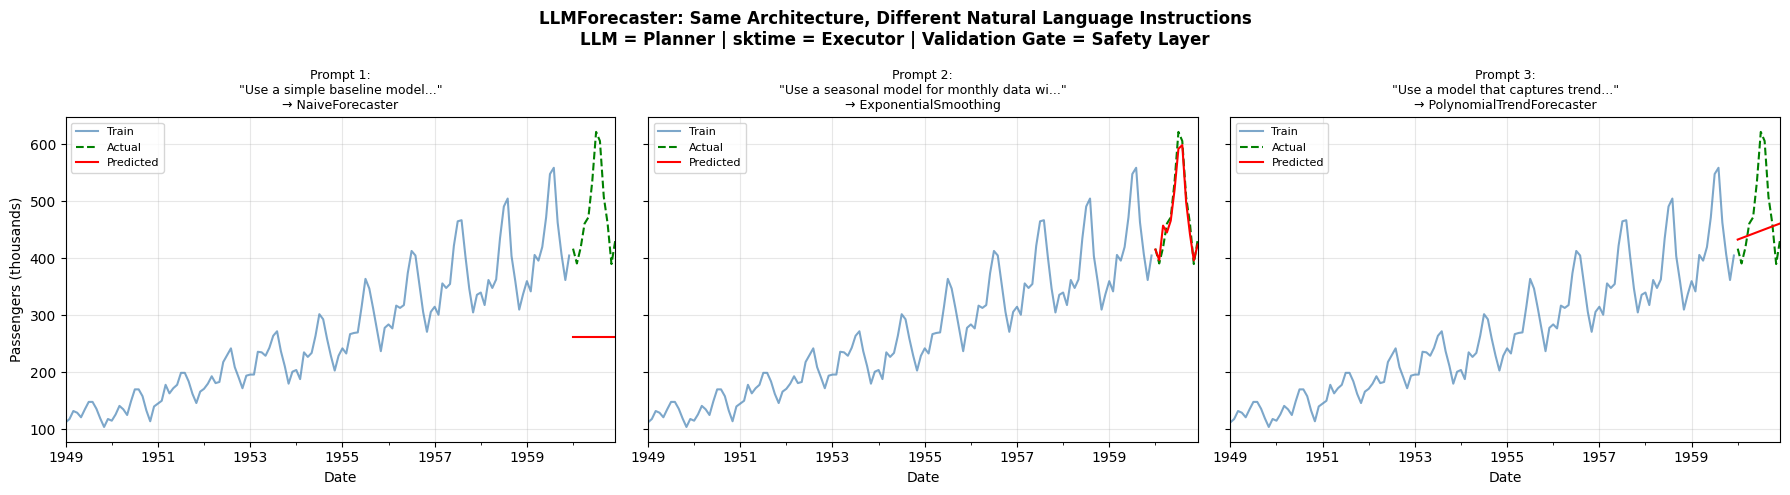


✅ Notebook complete!

📦 What this demonstrates:
   1. Natural language → automatic model selection
   2. Validation gate catches hallucinations before they reach user
   3. Fully pluggable LLM backend (rule-based, Gemini, OpenAI, mock)
   4. Pure sktime execution — deterministic, testable, composable
   5. No hard dependencies — works offline with any callable


In [27]:
# Cell 8: Final comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (result, ax) in enumerate(zip(prompts_and_results, axes)):
    y_train.plot(ax=ax, label="Train", color="steelblue", alpha=0.7)
    y_test.plot(ax=ax, label="Actual", color="green", linestyle="--")
    result["predictions"].plot(ax=ax, label=f"Predicted", color="red")
    
    ax.set_title(
        f"Prompt {i+1}:\n\"{result['prompt'][:40]}...\"\n"
        f"→ {result['selected']}",
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")

axes[0].set_ylabel("Passengers (thousands)")

fig.suptitle(
    "LLMForecaster: Same Architecture, Different Natural Language Instructions\n"
    "LLM = Planner | sktime = Executor | Validation Gate = Safety Layer",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("llm_forecaster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Notebook complete!")
print("\n📦 What this demonstrates:")
print("   1. Natural language → automatic model selection")
print("   2. Validation gate catches hallucinations before they reach user")
print("   3. Fully pluggable LLM backend (rule-based, Gemini, OpenAI, mock)")
print("   4. Pure sktime execution — deterministic, testable, composable")
print("   5. No hard dependencies — works offline with any callable")